# Régression Linéaire Simple et Multiple et La Régression Logistique

#  ❖ Régression Linéaire Simple

Question 1 : 

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

Question 2 : 

In [ ]:

df = pd.read_csv('Salary_Data.csv')
print(df.head(5))

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


Question 3 :

In [3]:
X = df[['YearsExperience']]
y = df[['Salary']]


Question 4 :

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=40 )

Question 5 :

In [8]:
regressor = LinearRegression()

Question 6 :

In [9]:
regressor.fit(X_train , y_train )
y_pred = regressor.predict(X_test)
print (y_pred)
print(y_pred.shape)

[[41434.13316677]
 [74801.31604849]
 [83143.11176892]
 [69240.11890153]
 [72947.58366617]
 [65532.6541369 ]]
(6, 1)


Question 7 :

In [10]:
print(regressor.predict([[15]]))
print(regressor.coef_)

[[166561.06897321]]
[[9268.66191159]]


c:\Users\ilyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Question 8 :

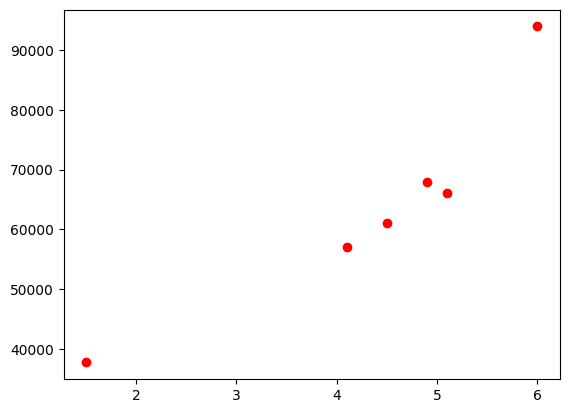

In [11]:
plt.scatter(X_test , y_test , c = 'r' )
#plt.plot(X_test, y_pred, c='r')

Question 9 :

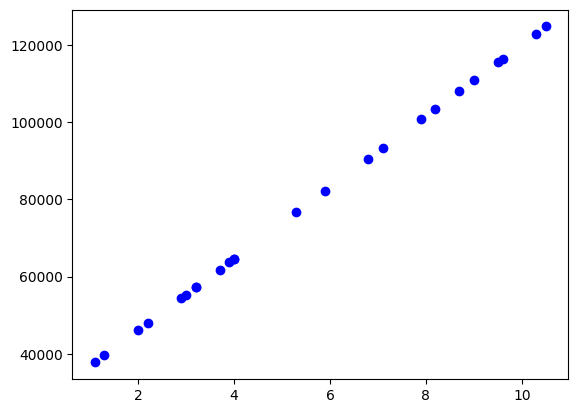

In [12]:
plt.scatter(X_train , regressor.predict(X_train) , c = 'b' )


Question 10:

- Les points rouges (test) sont proches de la droite bleue → le modèle généralise bien.
- La relation est quasi-linéaire entre expérience et salaire.


Question 11 :

In [14]:
a = float(regressor.coef_[0])
b = float(regressor.intercept_)
print(f"Coefficient a (pente)     : {a:.2f}")
print(f"Intercept  b              : {b:.2f}")
print(f"Équation : y = {a:.2f}x + {b:.2f}")

Coefficient a (pente)     : 9268.66
Intercept  b              : 27531.14
Équation : y = 9268.66x + 27531.14


C:\Users\ilyas\AppData\Local\Temp\ipykernel_16084\2302395927.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a = float(regressor.coef_[0])
C:\Users\ilyas\AppData\Local\Temp\ipykernel_16084\2302395927.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b = float(regressor.intercept_)


Question 12 :

In [17]:
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")

R² Score : 0.7775
MSE      : 61641413.31
RMSE     : 7851.20


Question 13 :

In [18]:
print(f"Min de y : {y.min()}")
print(f"Max de y : {y.max()}")

Min de y : Salary    37731.0
dtype: float64
Max de y : Salary    122391.0
dtype: float64


# patie 2 :

# ❖Régression Linéaire Multiple

Question 1 : 

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE

Question 2 :

In [21]:
dataset = pd.read_csv('50_Startups.csv')
print(dataset.head())
print(dataset.shape)

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
(50, 5)


Question 3 :

In [22]:
X = dataset.iloc[:, :-1].values 
y = dataset.iloc[:, -1].values

Question 4:

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [3])],  # colonne 3 = State
    remainder='passthrough'
)
X = np.array(ct.fit_transform(X))
X = X[:, 1:]

print("Shape de X après encodage :", X.shape)

Question 5 :

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

In [ ]:
y_pred = regressor.predict(X_test)
print("\nComparaison y_pred vs y_test :")
print(np.concatenate((y_pred.reshape(-1,1), y_test.reshape(-1,1)), axis=1))

In [ ]:
prediction = regressor.predict(np.array([[1, 0, 0, 130000, 140000, 300000]]))
print(f"\nPrédiction profit : {prediction[0]:.2f} $")


In [ ]:
print(f"\nIntercept : {regressor.intercept_:.2f}")
print(f"Coefficients : {regressor.coef_}")


In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"\nR² Score : {r2:.4f}")


In [ ]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=3)
rfe.fit(X_train, y_train)

print("\nVariables sélectionnées par RFE :", rfe.support_)
print("Ranking des variables            :", rfe.ranking_)


X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

regressor_rfe = LinearRegression()
regressor_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = regressor_rfe.predict(X_test_rfe)
r2_rfe = r2_score(y_test, y_pred_rfe)
print(f"R² Score après RFE (3 variables) : {r2_rfe:.4f}")